In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explaination: str

In [4]:
def generate_joke(state: JokeState):

    prompt= f'Generate a joke on the topic {state["topic"]}'
    response=llm.invoke(prompt).content

    return {'joke':response}

In [5]:
def generation_explaination(state: JokeState):

    prompt=f'Write an explaination for the joke- {state["joke"]}'
    response=llm.invoke(prompt).content
    
    return {'explaination':response}

In [6]:
graph=StateGraph(JokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explaination',generation_explaination)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explaination')
graph.add_edge('generate_explaination',END)

checkpointer=InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

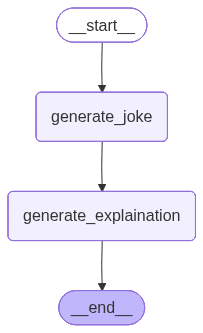

In [7]:
workflow

In [8]:
config1={"configurable": {"thread_id":"1"}}
workflow.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza get into a fight?\n\nBecause it kept saying, "You want a **pizza** me?!"',
 'explaination': 'This joke is a classic example of a **pun**, which is a form of wordplay that exploits multiple meanings of a word, or words that sound similar but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **The Setup:** "Why did the pizza get into a fight?" This sets up an absurd scenario, as pizzas don\'t actually fight. This signals that the answer will involve wordplay.\n\n2.  **The Punchline:** "Because it kept saying, \'You want a **pizza** me?!\'"\n\n3.  **The Pun:** The humor comes from the phrase "You want a **pizza** me?!" which sounds almost identical to the common aggressive idiom:\n    *   "You want a **piece** of me?!"\n\n4.  **The Idiom Explained:** "You want a piece of me?" is an aggressive challenge. It\'s what someone says when they are instigating a fight, asking if the other person wants to start trouble, or if they are looking 

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get into a fight?\n\nBecause it kept saying, "You want a **pizza** me?!"', 'explaination': 'This joke is a classic example of a **pun**, which is a form of wordplay that exploits multiple meanings of a word, or words that sound similar but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **The Setup:** "Why did the pizza get into a fight?" This sets up an absurd scenario, as pizzas don\'t actually fight. This signals that the answer will involve wordplay.\n\n2.  **The Punchline:** "Because it kept saying, \'You want a **pizza** me?!\'"\n\n3.  **The Pun:** The humor comes from the phrase "You want a **pizza** me?!" which sounds almost identical to the common aggressive idiom:\n    *   "You want a **piece** of me?!"\n\n4.  **The Idiom Explained:** "You want a piece of me?" is an aggressive challenge. It\'s what someone says when they are instigating a fight, asking if the other person wants to start trouble, or i

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get into a fight?\n\nBecause it kept saying, "You want a **pizza** me?!"', 'explaination': 'This joke is a classic example of a **pun**, which is a form of wordplay that exploits multiple meanings of a word, or words that sound similar but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **The Setup:** "Why did the pizza get into a fight?" This sets up an absurd scenario, as pizzas don\'t actually fight. This signals that the answer will involve wordplay.\n\n2.  **The Punchline:** "Because it kept saying, \'You want a **pizza** me?!\'"\n\n3.  **The Pun:** The humor comes from the phrase "You want a **pizza** me?!" which sounds almost identical to the common aggressive idiom:\n    *   "You want a **piece** of me?!"\n\n4.  **The Idiom Explained:** "You want a piece of me?" is an aggressive challenge. It\'s what someone says when they are instigating a fight, asking if the other person wants to start trouble, or 

In [11]:
config2 = {"configurable":{"thread_id":"2"}}
workflow.invoke({'topic':"pasta"},config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti break up with the linguine?\n\nIt felt like they were getting into too many saucy arguments, and it just wanted to be a *penne* for its thoughts!',
 'explaination': 'This joke is a classic example of a pun, relying on wordplay and the phonetic similarity between words. Here\'s the breakdown:\n\n1.  **Anthropomorphism:** The joke treats spaghetti and linguine (types of pasta) as if they are people in a relationship, capable of breaking up and having arguments. This immediately sets a lighthearted, silly tone.\n\n2.  **"Saucy arguments":** This is the first pun.\n    *   **Literal meaning (pasta context):** Arguments that involve sauce, or arguments over what kind of sauce to have.\n    *   **Figurative meaning (human context):** "Saucy" can mean impertinent, cheeky, or even a bit rude. So, "saucy arguments" refers to arguments that were a bit spicy, disrespectful, or just too much.\n    *   The humor comes from applying this double mean

In [12]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the linguine?\n\nIt felt like they were getting into too many saucy arguments, and it just wanted to be a *penne* for its thoughts!', 'explaination': 'This joke is a classic example of a pun, relying on wordplay and the phonetic similarity between words. Here\'s the breakdown:\n\n1.  **Anthropomorphism:** The joke treats spaghetti and linguine (types of pasta) as if they are people in a relationship, capable of breaking up and having arguments. This immediately sets a lighthearted, silly tone.\n\n2.  **"Saucy arguments":** This is the first pun.\n    *   **Literal meaning (pasta context):** Arguments that involve sauce, or arguments over what kind of sauce to have.\n    *   **Figurative meaning (human context):** "Saucy" can mean impertinent, cheeky, or even a bit rude. So, "saucy arguments" refers to arguments that were a bit spicy, disrespectful, or just too much.\n    *   The humor comes from applyi

In [13]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the linguine?\n\nIt felt like they were getting into too many saucy arguments, and it just wanted to be a *penne* for its thoughts!', 'explaination': 'This joke is a classic example of a pun, relying on wordplay and the phonetic similarity between words. Here\'s the breakdown:\n\n1.  **Anthropomorphism:** The joke treats spaghetti and linguine (types of pasta) as if they are people in a relationship, capable of breaking up and having arguments. This immediately sets a lighthearted, silly tone.\n\n2.  **"Saucy arguments":** This is the first pun.\n    *   **Literal meaning (pasta context):** Arguments that involve sauce, or arguments over what kind of sauce to have.\n    *   **Figurative meaning (human context):** "Saucy" can mean impertinent, cheeky, or even a bit rude. So, "saucy arguments" refers to arguments that were a bit spicy, disrespectful, or just too much.\n    *   The humor comes from apply

## Time Travel

In [18]:
workflow.get_state({"configurable":{"thread_id":2, "checkpoint_id":"1f16f1ce-3ccc-6771-8001-51235e921845"}})

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the linguine?\n\nIt felt like they were getting into too many saucy arguments, and it just wanted to be a *penne* for its thoughts!'}, next=('generate_explaination',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f16f1ce-3ccc-6771-8001-51235e921845'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-23T16:02:09.681188+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f1cd-f87a-64a0-8000-6ad9112643dd'}}, tasks=(PregelTask(id='68d65e6a-75a5-3f0d-cdbd-a028985724be', name='generate_explaination', path=('__pregel_pull', 'generate_explaination'), error=None, interrupts=(), state=None, result={'explaination': 'This joke is a classic example of a pun, relying on wordplay and the phonetic similarity between words. Here\'s the breakdown:\n\n1.  **Anthropomorphism:** The joke treats spaghetti and linguine (types of past

In [21]:
workflow.invoke(None, {"configurable":{"thread_id":2, "checkpoint_id":"1f16f1ce-3ccc-6771-8001-51235e921845"}})

{'topic': 'pasta',
 'joke': 'Why did the spaghetti break up with the linguine?\n\nIt felt like they were getting into too many saucy arguments, and it just wanted to be a *penne* for its thoughts!',
 'explaination': 'This joke is a classic example of **wordplay** and **puns**, using terms related to pasta and food to describe human relationship issues.\n\nLet\'s break it down:\n\n1.  **"Saucy arguments"**:\n    *   **Literal meaning (food context):** Pasta, like spaghetti and linguine, is often served with sauce. So, "saucy" directly relates to their food nature.\n    *   **Figurative meaning (human context):** "Saucy" can also mean cheeky, disrespectful, impertinent, or prone to heated, somewhat spicy arguments. So, their fights were "saucy" in two ways!\n\n2.  **"Penne for its thoughts"**:\n    *   **Penne (pasta):** This is a type of short, tube-shaped pasta.\n    *   **"A penny for your thoughts" (idiom):** This is a very common English idiom used to ask someone what they are think

In [22]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the linguine?\n\nIt felt like they were getting into too many saucy arguments, and it just wanted to be a *penne* for its thoughts!', 'explaination': 'This joke is a classic example of **wordplay** and **puns**, using terms related to pasta and food to describe human relationship issues.\n\nLet\'s break it down:\n\n1.  **"Saucy arguments"**:\n    *   **Literal meaning (food context):** Pasta, like spaghetti and linguine, is often served with sauce. So, "saucy" directly relates to their food nature.\n    *   **Figurative meaning (human context):** "Saucy" can also mean cheeky, disrespectful, impertinent, or prone to heated, somewhat spicy arguments. So, their fights were "saucy" in two ways!\n\n2.  **"Penne for its thoughts"**:\n    *   **Penne (pasta):** This is a type of short, tube-shaped pasta.\n    *   **"A penny for your thoughts" (idiom):** This is a very common English idiom used to ask someone

## Updating State

In [26]:
workflow.update_state({"configurable":{"thread_id":"2", "checkpoint_id":"1f16f1cd-f87a-64a0-8000-6ad9112643dd","checkpoint_ns": ""}},{'topic':'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16f1dd-683f-6c07-8001-cf9a35064fb6'}}

In [27]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f1dd-683f-6c07-8001-cf9a35064fb6'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-23T16:08:56.889687+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16f1cd-f87a-64a0-8000-6ad9112643dd'}}, tasks=(PregelTask(id='2b5cc989-060f-c746-2a49-ee60cfa006c8', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti break up with the linguine?\n\nIt felt like they were getting into too many saucy arguments, and it just wanted to be a *penne* for its thoughts!', 'explaination': 'This joke is a classic example of **wordplay** and **puns**, using terms related to pasta and food to describe human relationship issues.\n\nLe

In [29]:
workflow.invoke(None, {"configurable":{"thread_id":2, "checkpoint_id":"1f16f1dd-683f-6c07-8001-cf9a35064fb6"}})


{'topic': 'samosa',
 'joke': 'Why did the samosa get an award for its debating skills?\n\nBecause it always had a **sharp point**!',
 'explaination': 'This joke is a pun that plays on the double meaning of the phrase "sharp point."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (Samosa):** A samosa is a triangular fried pastry. Physically, it often has a distinct, **sharp point** or corner where its edges meet.\n\n2.  **Figurative Meaning (Debating):** In the context of debating, having a "sharp point" means having a very clear, insightful, well-articulated, and often persuasive argument or idea. It\'s a key, impactful statement that gets straight to the core of an issue.\n\nThe humor comes from the unexpected link between the **physical characteristic** of the samosa (its pointy shape) and the **intellectual quality** of a good debater (making incisive arguments). It creates a silly image of a food item being praised for its intellectual prowess based on its literal shape!'}

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa get an award for its debating skills?\n\nBecause it always had a **sharp point**!', 'explaination': 'This joke is a pun that plays on the double meaning of the phrase "sharp point."\n\nHere\'s the breakdown:\n\n1.  **Literal Meaning (Samosa):** A samosa is a triangular fried pastry. Physically, it often has a distinct, **sharp point** or corner where its edges meet.\n\n2.  **Figurative Meaning (Debating):** In the context of debating, having a "sharp point" means having a very clear, insightful, well-articulated, and often persuasive argument or idea. It\'s a key, impactful statement that gets straight to the core of an issue.\n\nThe humor comes from the unexpected link between the **physical characteristic** of the samosa (its pointy shape) and the **intellectual quality** of a good debater (making incisive arguments). It creates a silly image of a food item being praised for its intellectual prowess based on its li